# Tutorial on learning energies and forces from SOAP and SOAP gradients.
In this tutorial, we use the MD17 dataset (benzenes only) and SOAP featurization + Linear Regression to find parameters that fit energies and forces. We first show a proof-of-concept with a small subset of frames, and then we expand later.


## Table of Contents:
* [AniSOAP and SOAP Proof of Concept Unified Function](#anisoap-soap-unified)
  * This is the most up to date version (unifies the next three versions) as of 29 Jan 2026
* [Proof Of Concept: 1000 frames](#n-1000)
* [Mixed Forces and Energies in Training](#mixed-train-small)
* [AniSOAP try](#anisoap)

# AniSOAP and SOAP Proof of Concept Unified Function<a class="anchor" id="anisoap-soap-unified"></a>


In [440]:
# Load in the data
from ase import Atoms
import numpy as np

dataset = np.load("/Users/alin62/Downloads/md17_benzene2017.npz")
print(list(dataset.keys()))
n_frames=1000

energies = dataset['E'][:n_frames]
forces = dataset['F'][:n_frames]
positions = dataset['R'][:n_frames]
atom_numbers = dataset['z'][:n_frames]

from anisoap.representations import EllipsoidalDensityProjection
# create 1000 frames for featomic
frames = []
for i in range(n_frames):
    frame = Atoms(symbols=atom_numbers, positions=positions[i])
    frame.arrays["c_diameter[1]"] = np.ones(len(frame))
    frame.arrays["c_diameter[2]"] = np.ones(len(frame))
    frame.arrays["c_diameter[3]"] = np.ones(len(frame))
    frame.arrays["c_q"] = np.array([[1,0,0,0]]*len(frame))
    frames.append(frame)
print(f"{len(frames)=}")

['E', 'name', 'F', 'theory', 'R', 'z', 'type', 'md5']
len(frames)=1000


In [460]:
import metatensor
from metatensor import TensorMap, TensorBlock
from skmatter.preprocessing import StandardFlexibleScaler
from skmatter.metrics import global_reconstruction_error as GRE

def find_gfre(soap_rep:TensorMap, anisoap_rep:TensorMap):
    rep = soap_rep    # First process soap rep
    rep = rep.keys_to_samples("center_type")
    rep = rep.keys_to_properties(["neighbor_1_type", "neighbor_2_type"])
    rep = metatensor.mean_over_samples(rep, ["atom", "center_type"])
    X_soap_unnorm = rep.block().values.squeeze()
    X_soap_gradx_unnorm = rep.block().gradient("positions").values[:,0,:]

    rep = anisoap_rep  # Then, process anisoap rep
    rep = rep.keys_to_samples("types_center")
    rep = metatensor.mean_over_samples(rep, ["center", "types_center"])
    X_anisoap_unnorm = rep.block().values.squeeze()
    X_anisoap_gradx_unnorm = rep.block().gradient("positions").values[:,0,0,:]

    print(f"{GRE(X_anisoap_unnorm, X_soap_unnorm)=}")
    print(f"{GRE(X_anisoap_gradx_unnorm, X_soap_gradx_unnorm)=}")




def train_energies(rep:TensorMap, e:np.ndarray, f:np.ndarray, mode="soap"):
    """
    Train a model on energies only, and return performance on energies and forces.
    rep: TensorMap, unnormalized SOAP or AniSOAP feature, containing gradients.
    e: np.ndarray, unnormalized energies
    f: np.ndarray, unnormalized forces
    mode: "soap" or "anisoap", for processing reps to become values.
    """


    # Extract unnormalized features from TensorMap
    if mode == "soap":
        rep = rep.keys_to_samples("center_type")
        rep = rep.keys_to_properties(["neighbor_1_type", "neighbor_2_type"])
        rep = metatensor.mean_over_samples(rep, ["atom", "center_type"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,:]
    elif mode == "anisoap":
        rep = rep.keys_to_samples("types_center")
        rep = metatensor.mean_over_samples(rep, ["center", "types_center"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,0,:]
        
    else:
        raise ValueError("mode must be 'soap' or 'anisoap'")    
    # Create normalized features
    X_scaler = StandardFlexibleScaler(column_wise=False).fit(X_unnorm)
    X = X_scaler.transform(X_unnorm)
    X_gradx_scaler = StandardFlexibleScaler(column_wise=False).fit(X_gradx_unnorm)
    X_gradx = X_gradx_scaler.transform(X_gradx_unnorm)

    # Normalize the forces and energies. Note that y_ngradx is the negative of dy/dx
    y_scaler = StandardFlexibleScaler(column_wise=True).fit(e)
    y = y_scaler.transform(e)

    # Stack the forces' x component
    fx = f[:,:,0].reshape(-1,1)
    y_ngradx_scaler = StandardFlexibleScaler(column_wise=True).fit(fx)
    y_ngradx = y_ngradx_scaler.transform(fx)

    print(f"{X.shape=}")
    print(f"{X_gradx.shape=}")
    print(f"{y.shape=}")
    print(f"{y_ngradx.shape=}")

    from sklearn.linear_model import RidgeCV
    lr = RidgeCV(alphas=np.logspace(-8,2,12), cv=5)
    lr.fit(X, y)
    print("-"*30)
    print(f"{mode=}")
    print(f"{lr.score(X,y)=:.3f}")
    print(f"{lr.score(-X_gradx, y_ngradx)=:.3f}")


def train_mixed(rep:TensorMap, e:np.ndarray, f:np.ndarray, mode="soap"):
    """
    Train a model on energies and forces, and return performance on energies and forces.
    rep: TensorMap, unnormalized SOAP or AniSOAP feature, containing gradients.
    e: np.ndarray, unnormalized energies
    f: np.ndarray, unnormalized forces
    mode: "soap" or "anisoap", for processing reps to become values.
    """


    # Extract unnormalized features from TensorMap
    if mode == "soap":
        rep = rep.keys_to_samples("center_type")
        rep = rep.keys_to_properties(["neighbor_1_type", "neighbor_2_type"])
        rep = metatensor.mean_over_samples(rep, ["atom", "center_type"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,:]
    elif mode == "anisoap":
        rep = rep.keys_to_samples("types_center")
        rep = metatensor.mean_over_samples(rep, ["center", "types_center"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,0,:]
        
    else:
        raise ValueError("mode must be 'soap' or 'anisoap'")    
    # Create normalized features
    X_scaler = StandardFlexibleScaler(column_wise=False).fit(X_unnorm)
    X = X_scaler.transform(X_unnorm)
    X_gradx_scaler = StandardFlexibleScaler(column_wise=False).fit(X_gradx_unnorm)
    X_gradx = X_gradx_scaler.transform(X_gradx_unnorm)

    # Normalize the forces and energies. Note that y_ngradx is the negative of dy/dx
    y_scaler = StandardFlexibleScaler(column_wise=True).fit(e)
    y = y_scaler.transform(e)

    # Stack the forces' x component
    fx = f[:,:,0].reshape(-1,1)
    y_ngradx_scaler = StandardFlexibleScaler(column_wise=True).fit(fx)
    y_ngradx = y_ngradx_scaler.transform(fx)

    print(f"{X.shape=}")
    print(f"{X_gradx.shape=}")
    print(f"{y.shape=}")
    print(f"{y_ngradx.shape=}")

    # Stack
    X_cat_train = np.vstack((X[:len(X)//2], -X_gradx[:len(X_gradx)//2]))
    y_cat_train = np.vstack((y[:len(y)//2], y_ngradx[:len(y_ngradx)//2]))
    from sklearn.linear_model import RidgeCV
    lr = RidgeCV(alphas=np.logspace(-8,2,12), cv=5)
    lr.fit(X_cat_train, y_cat_train)
    print("-"*30)
    print(f"{mode=}")
    print(f"{lr.score(X_cat_train,y_cat_train)=:.3f}")
    print(f"{lr.score(X,y)=:.3f}")
    print(f"{lr.score(-X_gradx, y_ngradx)=:.3f}")

def create_pca(rep:TensorMap, e:np.ndarray, f:np.ndarray, mode='soap'):
    if mode == "soap":
        rep = rep.keys_to_samples("center_type")
        rep = rep.keys_to_properties(["neighbor_1_type", "neighbor_2_type"])
        rep = metatensor.mean_over_samples(rep, ["atom", "center_type"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,:]
    elif mode == "anisoap":
        rep = rep.keys_to_samples("types_center")
        rep = metatensor.mean_over_samples(rep, ["center", "types_center"])
        X_unnorm = rep.block().values.squeeze()
        X_gradx_unnorm = rep.block().gradient("positions").values[:,0,0,:]
        
    else:
        raise ValueError("mode must be 'soap' or 'anisoap'")    
    # Create normalized features
    X_scaler = StandardFlexibleScaler(column_wise=False).fit(X_unnorm)
    X = X_scaler.transform(X_unnorm)
    X_gradx_scaler = StandardFlexibleScaler(column_wise=False).fit(X_gradx_unnorm)
    X_gradx = X_gradx_scaler.transform(X_gradx_unnorm)

    # Normalize the forces and energies. Note that y_ngradx is the negative of dy/dx
    y_scaler = StandardFlexibleScaler(column_wise=True).fit(e.reshape(-1,1))
    y = y_scaler.transform(e.reshape(-1,1))

    # Stack the forces' x component
    fx = f[:,:,0].reshape(-1,1)
    y_ngradx_scaler = StandardFlexibleScaler(column_wise=True).fit(fx)
    y_ngradx = y_ngradx_scaler.transform(fx)

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(X)
    t_pca = pca.transform(X)
    print(t_pca.shape)
    plt.scatter(t_pca[:,0], t_pca[:,1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2 ")
    plt.colorbar(label="energies_normalized")
    plt.title(f"PCA {mode}")
    plt.show()

    pca.fit(X_gradx)
    t_pca = pca.transform(X_gradx)
    plt.scatter(t_pca[:,0], t_pca[:,1], c=fx)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label="forces_normalized")
    plt.title(f"PCA {mode} Gradients")

========== Train Only Energies ==========
X.shape=(1000, 735)
X_gradx.shape=(12000, 735)
y.shape=(1000, 1)
y_ngradx.shape=(12000, 1)
------------------------------
mode='soap'
lr.score(X,y)=1.000
lr.score(-X_gradx, y_ngradx)=0.883
========== Train Mixed ==========
X.shape=(1000, 735)
X_gradx.shape=(12000, 735)
y.shape=(1000, 1)
y_ngradx.shape=(12000, 1)
------------------------------
mode='soap'
lr.score(X_cat_train,y_cat_train)=0.998
lr.score(X,y)=0.969
lr.score(-X_gradx, y_ngradx)=0.999
(1000, 2)


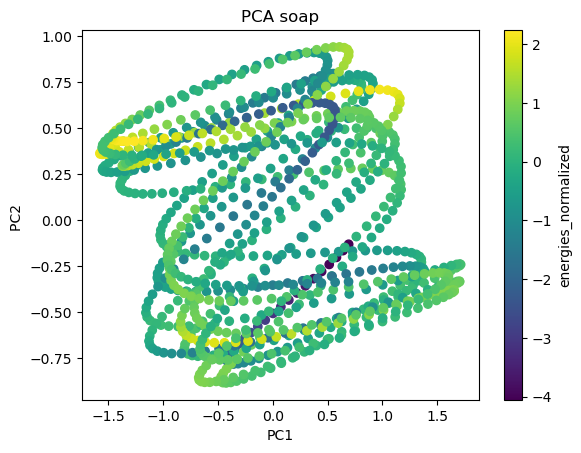

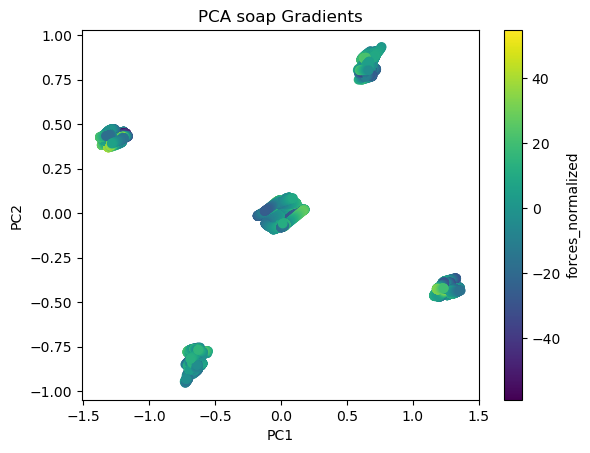

In [461]:
lmax=4
nmax=6

from featomic.calculators import SoapPowerSpectrum
HYPER_PARAMETERS = {
    "cutoff": {
        "radius": 5.0,
        "smoothing": {"type": "ShiftedCosine", "width": 0.5},
    },
    "density": {
        "type": "Gaussian",
        "width": 0.3,
    },
    "basis": {
        "type": "TensorProduct",
        "max_angular": lmax,
        "radial": {"type": "Gto", "max_radial": nmax},
    },
}

calculator = SoapPowerSpectrum(**HYPER_PARAMETERS)
descriptor = calculator.compute(frames, gradients=['positions'])
print("="*10, "Train Only Energies", "="*10)
train_energies(descriptor, energies, forces)
print("="*10, "Train Mixed", "="*10)
train_mixed(descriptor, energies, forces)
create_pca(descriptor, energies, forces)

In [462]:
lmax = 4
nmax = 5   # Corresponds with nmax=6 for featomic's SOAP

AniSOAP_HYPERS = {
    "max_angular": lmax,
    "max_radial": nmax,
    "radial_basis_name": "gto",
    "rotation_type": "quaternion",
    "rotation_key": "c_q",
    "cutoff_radius": 7.0,
    "radial_gaussian_width": 1.5,
    "basis_rcond": 1e-8,
    "basis_tol": 1e-4,
}
calculator = EllipsoidalDensityProjection(**AniSOAP_HYPERS)
mvg_coeffs = calculator.transform(frames, show_progress=True, normalize=True, rust_moments=False, compute_gradients=True)   # Takes time.

/Users/alin62/Documents/Research/anisoap/anisoap/representations/ellipsoidal_density_projection.py:636: UserWarning: In quaternion mode, quaternions are assumed to be in (w,x,y,z) format.
  warnings.warn(
Computing neighborlist: 100%|██████████| 1000/1000 [00:00<00:00, 13816.55it/s]


In [463]:
from anisoap.utils.metatensor_utils import (
    ClebschGordanReal,
    cg_combine,
    standardize_keys,
)
import metatensor

mvg_nu1 = standardize_keys(mvg_coeffs)  # standardize the metadata naming schemes
# Create an object that stores Clebsch-Gordan coefficients for a certain lmax:
mycg = ClebschGordanReal(lmax)

# Combines the mvg_nu1 with itself using the Clebsch-Gordan coefficients.
# This combines the angular and radial components of the sample.
mvg_nu2 = cg_combine(
    mvg_nu1,
    mvg_nu1,
    clebsch_gordan=mycg,
    lcut=0,
    other_keys_match=["types_center"],
)


========== Train Only Energies ==========
X.shape=(1000, 720)
X_gradx.shape=(12000, 720)
y.shape=(1000, 1)
y_ngradx.shape=(12000, 1)
------------------------------
mode='anisoap'
lr.score(X,y)=1.000
lr.score(-X_gradx, y_ngradx)=-0.756
========== Train Mixed ==========
X.shape=(1000, 720)
X_gradx.shape=(12000, 720)
y.shape=(1000, 1)
y_ngradx.shape=(12000, 1)
------------------------------
mode='anisoap'
lr.score(X_cat_train,y_cat_train)=0.557
lr.score(X,y)=0.909
lr.score(-X_gradx, y_ngradx)=0.476
(1000, 2)


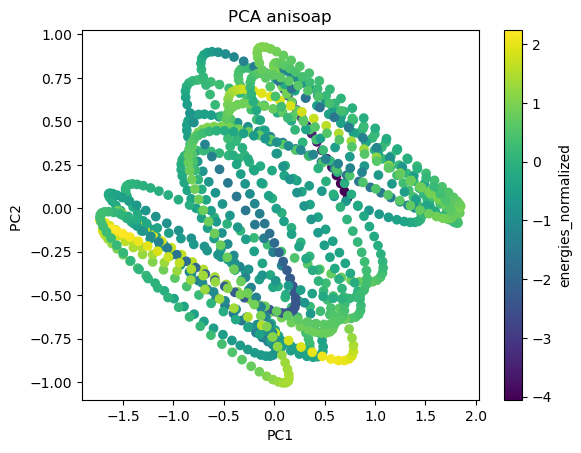

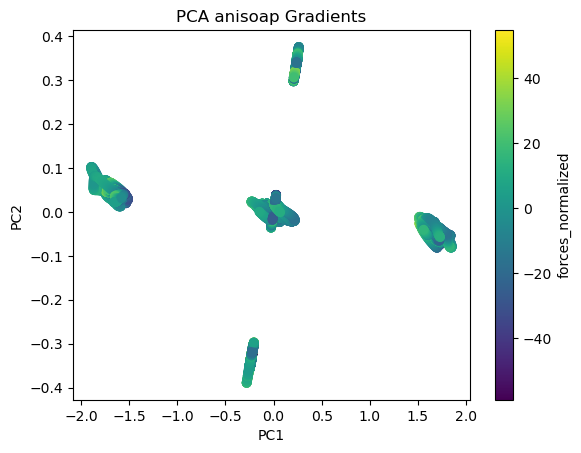

In [466]:
print("="*10, "Train Only Energies", "="*10)
train_energies(mvg_nu2, energies, forces, mode='anisoap')
print("="*10, "Train Mixed", "="*10)
train_mixed(mvg_nu2, energies, forces, mode='anisoap')
create_pca(mvg_nu2, energies, forces, mode='anisoap')

In [439]:
find_gfre(descriptor, mvg_nu2)

GRE(X_anisoap_unnorm, X_soap_unnorm)=np.float64(0.0009144722853765822)
GRE(X_anisoap_gradx_unnorm, X_soap_gradx_unnorm)=np.float64(0.00999913592652329)


## Proof of concept with 1000 frames <a class="anchor" id="n-1000"></a>

In [160]:
from ase.io import read
from ase import Atoms
import numpy as np
n_frames = 100

In [161]:
dataset = np.load("/Users/alin62/Downloads/md17_benzene2017.npz")
list(dataset.keys())

['E', 'name', 'F', 'theory', 'R', 'z', 'type', 'md5']

In [162]:
energies = dataset['E']
forces = dataset['F']
positions = dataset['R']
atom_numbers = dataset['z']

In [4]:
# create 1000 frames for featomic
frames = []
for i in range(n_frames):
    frames.append(Atoms(symbols=atom_numbers, positions=positions[i]))


There is one energy per frame (total energy), but 12 forces per frame (one force on each atom's position)\
Note that energies and forces have very different orders of magnigudes - hints that normalization will be required later.

In [5]:
display(energies.shape)
display(forces.shape)
display(positions.shape)
print(f"Energy (min,max,mean,std): {energies.min():.3f}, {energies.max():.3f}, {energies.mean():.3f}, {energies.std():.3f}")
print(f"Force (min,max,mean,std):{forces.min():.3f}, {forces.max():.3f}, {forces.mean():.3f}, {forces.std():.3f}")

(627983, 1)

(627983, 12, 3)

(627983, 12, 3)

Energy (min,max,mean,std): -146536.119, -146513.636, -146527.279, 2.345
Force (min,max,mean,std):-126.677, 139.626, 0.000, 19.830


In [312]:
from featomic.calculators import SoapPowerSpectrum
HYPER_PARAMETERS = {
    "cutoff": {
        "radius": 5.0,
        "smoothing": {"type": "ShiftedCosine", "width": 0.5},
    },
    "density": {
        "type": "Gaussian",
        "width": 0.3,
    },
    "basis": {
        "type": "TensorProduct",
        "max_angular": 4,
        "radial": {"type": "Gto", "max_radial": 6},
    },
}

calculator = SoapPowerSpectrum(**HYPER_PARAMETERS)
# calculator = SphericalExpansion(**HYPER_PARAMETERS)
# calculator = SphericalExpansionByPair(**HYPER_PARAMETERS)


In [313]:
descriptor = calculator.compute(frames[:n_frames], gradients=['positions'])
# The original descriptor is a TensorMap with one tensor block per 3-body combination.
# It doesn't really matter what these are, because we will transform these with keys_to_samples and keys_to_properties.
display(descriptor)
display(descriptor.keys)
display(descriptor.block(0))
display(descriptor.block(0).gradient('positions'))

TensorMap with 6 blocks
keys: center_type  neighbor_1_type  neighbor_2_type
           1              1                1
           1              1                6
                          ...
           6              1                6
           6              6                6

Labels(
    center_type  neighbor_1_type  neighbor_2_type
         1              1                1
         1              1                6
         1              6                6
         6              1                1
         6              1                6
         6              6                6
)

TensorBlock
    samples (600): ['system', 'atom']
    components (): []
    properties (245): ['l', 'n_1', 'n_2']
    gradients: ['positions']

Gradient TensorBlock ('positions')
    samples (3472): ['sample', 'system', 'atom']
    components (3): ['xyz']
    properties (245): ['l', 'n_1', 'n_2']
    gradients: None

In [314]:
# descriptor.block(0).samples


In [315]:
# descriptor.block(0).gradient('positions').samples

In [316]:
print("before: ", len(descriptor.keys))

descriptor = descriptor.keys_to_samples("center_type")
descriptor = descriptor.keys_to_properties(["neighbor_1_type", "neighbor_2_type"])
print("after: ", len(descriptor.keys))


before:  6
after:  1


The descriptor has 12000 samples, (1 descriptor for each of the 12 atoms, for each of the 1000 frames) \
The gradient of the descriptor has nearly 144000 samples (the gradient of each of the atoms with respect to the other 12 atoms, for 1000 frames (12 \*12\*1000)). It's not exactly 144000 because not each of the 12 neighboring atoms are in the neighborlist of each other for every atom in every frame.

In [317]:
display(descriptor.block(0))
display(descriptor.block(0).gradient('positions'))

TensorBlock
    samples (1200): ['system', 'atom', 'center_type']
    components (): []
    properties (735): ['neighbor_1_type', 'neighbor_2_type', 'l', 'n_1', 'n_2']
    gradients: ['positions']

Gradient TensorBlock ('positions')
    samples (14272): ['sample', 'system', 'atom']
    components (3): ['xyz']
    properties (735): ['neighbor_1_type', 'neighbor_2_type', 'l', 'n_1', 'n_2']
    gradients: None

In [318]:
descriptor.block(0).samples

Labels(
    system  atom  center_type
      0      0         6
      0      1         6
      0      2         6
      0      3         6
      0      4         6
      0      5         6
      0      6         1
      0      7         1
      0      8         1
      0      9         1
      0      10        1
      0      11        1
      1      0         6
      1      1         6
      1      2         6
      1      3         6
      1      4         6
      1      5         6
      1      6         1
      1      7         1
      1      8         1
      1      9         1
      1      10        1
      1      11        1
      2      0         6
      2      1         6
      2      2         6
      2      3         6
      2      4         6
      2      5         6
      2      6         1
      2      7         1
      2      8         1
      2      9         1
      2      10        1
      2      11        1
      3      0         6
      3      1         6
      3     

In [319]:
descriptor.block(0).gradient("positions").samples

Labels(
    sample  system  atom
      0       0      0
      0       0      1
      0       0      2
      0       0      3
      0       0      4
      0       0      5
      0       0      6
      0       0      7
      0       0      8
      0       0      9
      0       0      10
      0       0      11
      1       0      0
      1       0      1
      1       0      2
      1       0      3
      1       0      4
      1       0      5
      1       0      6
      1       0      7
      1       0      8
      1       0      9
      1       0      10
      1       0      11
      2       0      0
      2       0      1
      2       0      2
      2       0      3
      2       0      4
      2       0      5
      2       0      6
      2       0      7
      2       0      8
      2       0      9
      2       0      10
      2       0      11
      3       0      0
      3       0      1
      3       0      2
      3       0      3
      3       0      4
      3       0   

Now, we aggregate over samples' individual atom types (can be mean or sum, doesn't matter - we do mean). After doing so, we will have one feature vector per frame, and 12 gradient feature vectors (1 for each atom) for each frame.

In [320]:
import metatensor
rep = metatensor.mean_over_samples(descriptor, sample_names=["atom", "center_type"])
display(rep.block(0))
display(rep.block(0).gradient("positions"))

TensorBlock
    samples (100): ['system']
    components (): []
    properties (735): ['neighbor_1_type', 'neighbor_2_type', 'l', 'n_1', 'n_2']
    gradients: ['positions']

Gradient TensorBlock ('positions')
    samples (1200): ['sample', 'system', 'atom']
    components (3): ['xyz']
    properties (735): ['neighbor_1_type', 'neighbor_2_type', 'l', 'n_1', 'n_2']
    gradients: None

In [321]:
rep.block(0).values.squeeze().shape

(100, 735)

In [322]:
energies.reshape(-1, 1).shape

(627983, 1)

## Now, we are ready to do regularized linear regression on energies and forces
Importantly, we have to scale and normalize the values to get parameters that can transfer between energies and forces.

In [323]:
from sklearn.linear_model import RidgeCV
from skmatter.preprocessing import StandardFlexibleScaler
scaled_e = StandardFlexibleScaler(column_wise=False).fit_transform(energies[:n_frames])
scaled_x = StandardFlexibleScaler(column_wise=False).fit_transform(rep.block(0).values.squeeze())
lr_energy = RidgeCV(alphas=np.logspace(-8, 2, 10), cv=5)
lr_energy.fit(scaled_x, scaled_e)
lr_energy.score(scaled_x, scaled_e)

0.9999999315054605

In [324]:
# The coefficients are fairly small and generally centered about 0, due to regularization.
print(f"LR coefficients (min,max,mean,std): {lr_energy.coef_.min():.3f}, {lr_energy.coef_.max():.3f},{lr_energy.coef_.mean():.3f},{lr_energy.coef_.std():.3f}")
print(lr_energy.coef_.shape)

LR coefficients (min,max,mean,std): -4.126, 5.160,0.039,0.831
(735,)


## Now, we are going to learn the individual force components.
For now, just focus on x component of force. 

In [325]:
rep.block(0).gradient('positions')

Gradient TensorBlock ('positions')
    samples (1200): ['sample', 'system', 'atom']
    components (3): ['xyz']
    properties (735): ['neighbor_1_type', 'neighbor_2_type', 'l', 'n_1', 'n_2']
    gradients: None

In [326]:
forces.shape

(627983, 12, 3)

In [327]:
lr_forces = RidgeCV(alphas=np.logspace(-8, 2, 10), cv=5)
scaled_f_x = StandardFlexibleScaler(column_wise=False).fit_transform(forces[:n_frames, :, 0].reshape(-1,1))
scaled_xgrad_x = StandardFlexibleScaler(column_wise=False).fit_transform(rep.block(0).gradient('positions').values[:, 0, :])

lr_forces.fit(scaled_xgrad_x, scaled_f_x)
lr_forces.score(scaled_xgrad_x, scaled_f_x)
# lr_forces.score(rep.block(0).gradient('positions').values[:, 0, :], forces[:n_frames, :, 0].reshape(-1,1))
# lr_forces.fit(rep.block(0).gradient('positions').values[:, :, :], forces[:n_frames].reshape(-1, 3))
# lr_forces.score(rep.block(0).gradient('positions').values[:, :, :], forces[:n_frames].reshape(-1, 3))

0.9999612857916964

# Above, we learned the x-component of the force through direct training - but, we can actually reuse the coefficients from the energies model
Notice that 
$$
\begin{align*}
F = -\nabla E = -\nabla (Xw) = -\nabla(X) w
\end{align*}
$$
So, because we used linear regression as our model, we can reuse our weights from the energies, and should be able to get good results.

In [328]:
# Now, test how well the linear regression on forces does with the energy weights 
lr_energy.score(-scaled_xgrad_x, scaled_f_x)

0.7390429457058223

Predicted scaled forces from energies
	 [-7.13239072e-04 -3.31640845e-01 -3.31640845e-01 ...  8.25202532e-01
  4.36696644e-01 -1.67508815e-01]
Actual scaled forces
	 [ 5.74813115e-11 -2.08783330e-01 -2.08783330e-01 ...  5.81940566e-01
  2.66560181e-01 -2.26482886e-01]


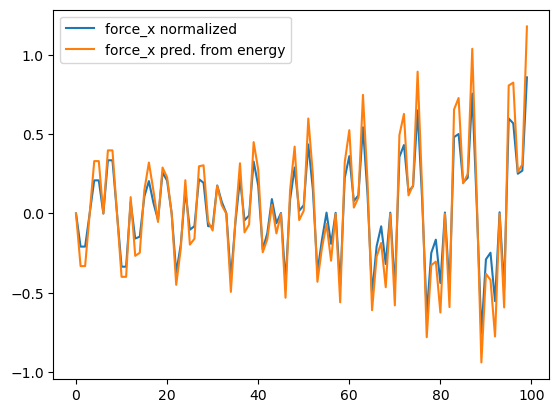

In [23]:
# We see that the force_x prediction from the energies model and the forces_x correspond!
print("Predicted scaled forces from energies\n\t", lr_energy.predict(-scaled_xgrad_x))
print("Actual scaled forces\n\t", scaled_f_x.flatten())
import matplotlib.pyplot as plt
plt.plot(scaled_f_x[:100], label="force_x normalized")
plt.plot(lr_energy.predict(-scaled_xgrad_x)[:100], label="force_x pred. from energy")
plt.legend()

Actual scaled energies
	 [-4.04397075 -4.05373939 -4.03782595 -3.99465483 -3.92611673 -3.83284189
 -3.71845417 -3.58484427 -3.43752674 -3.28091325]
Scaled energy predictions from forces model
	 [-3.11722587 -3.12581425 -3.11523424 -3.08428256 -3.03454216 -2.96643785
 -2.88236369 -2.78402956 -2.67560108 -2.56016339]


0.9334960345712019

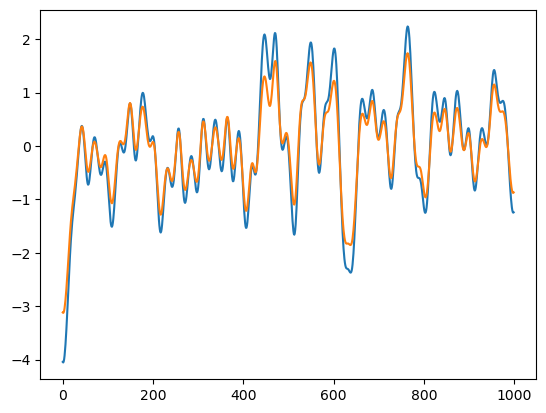

In [24]:
# We also see that the energy prediction from the forces_x model corresponds with the actual energies!
print("Actual scaled energies\n\t", scaled_e.flatten()[:10])
print("Scaled energy predictions from forces model\n\t", lr_forces.predict(-scaled_x)[:10])
import matplotlib.pyplot as plt
plt.plot(scaled_e)
plt.plot(lr_forces.predict(-scaled_x))
lr_forces.score(-scaled_x, scaled_e)

## Mixed forces and energies model on small dataset <a class="anchor" id="mixed-train-small"></a>
From our previous result, we can see the coefficients of energies and forces are transferrable. Training on both energies and forces should be able to yield us a more accurate, transferrable model.

In [25]:
display(rep.block().values.squeeze().shape)
display(rep.block().gradient("positions").values.shape)   # a simple reshape doesn't work since the (xyz) are in intermediate position. Need to manually vstack to make this work, as shown below..

# Prepare the feature matrix: concatenate the normalized features and the normalized negative of the three feature gradients) 
# Here, we will do things more properly and retain the actual scalers used, so we can inverse transform later.
rep_scaler = StandardFlexibleScaler(column_wise=False)
grad_x_scaler = StandardFlexibleScaler(column_wise=False)
grad_y_scaler = StandardFlexibleScaler(column_wise=False)
grad_z_scaler = StandardFlexibleScaler(column_wise=False)

rep_scaler.fit(rep.block().values.squeeze())
grad_x_scaler.fit(rep.block().gradient("positions").values[:,0,:])
grad_y_scaler.fit(rep.block().gradient("positions").values[:,1,:])
grad_z_scaler.fit(rep.block().gradient("positions").values[:,2,:])

scaled_rep = rep_scaler.transform(rep.block().values.squeeze())
scaled_grad_x = grad_x_scaler.transform(rep.block().gradient("positions").values[:,0,:])
scaled_grad_y = grad_y_scaler.transform(rep.block().gradient("positions").values[:,1,:])
scaled_grad_z = grad_z_scaler.transform(rep.block().gradient("positions").values[:,2,:])

# Don't forget these negative signs!
rep_cat = np.vstack((scaled_rep, -scaled_grad_x, -scaled_grad_y, -scaled_grad_z))
print(rep_cat.shape)

# Now, prepare the concatenated targets
e_scaler = StandardFlexibleScaler(column_wise=False)
f_x_scaler = StandardFlexibleScaler(column_wise=False)
f_y_scaler = StandardFlexibleScaler(column_wise=False)
f_z_scaler = StandardFlexibleScaler(column_wise=False)

e_scaler.fit(energies[:n_frames])
f_x_scaler.fit(forces[:n_frames, :, 0].flatten().reshape(-1,1))
f_y_scaler.fit(forces[:n_frames, :, 1].flatten().reshape(-1,1))
f_z_scaler.fit(forces[:n_frames, :, 2].flatten().reshape(-1,1))

scaled_e = e_scaler.transform(energies[:n_frames].reshape(-1,1))
scaled_f_x = f_x_scaler.transform(forces[:n_frames, :, 0].flatten().reshape(-1,1))
scaled_f_y = f_y_scaler.transform(forces[:n_frames, :, 1].flatten().reshape(-1,1))
scaled_f_z = f_z_scaler.transform(forces[:n_frames, :, 2].flatten().reshape(-1,1))

y_cat = np.vstack((scaled_e, scaled_f_x, scaled_f_y, scaled_f_z))
print(y_cat.shape)

(1000, 735)

(12000, 3, 735)

(37000, 735)
(37000, 1)


In [26]:
lr_cat = RidgeCV(alphas=np.logspace(-8,2,10), cv=5)
lr_cat.fit(rep_cat, y_cat)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+02])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [27]:
print(lr_cat.score(rep_cat, y_cat))
print(lr_cat.score(scaled_rep, scaled_e))
print(lr_cat.score(-scaled_grad_x, scaled_f_x))
print(lr_cat.score(-scaled_grad_y, scaled_f_y))
print(lr_cat.score(-scaled_grad_z, scaled_f_z))

0.9858331031865678
0.8775185474569123
0.9902355467725752
0.9949082050973886
0.9813817706672111


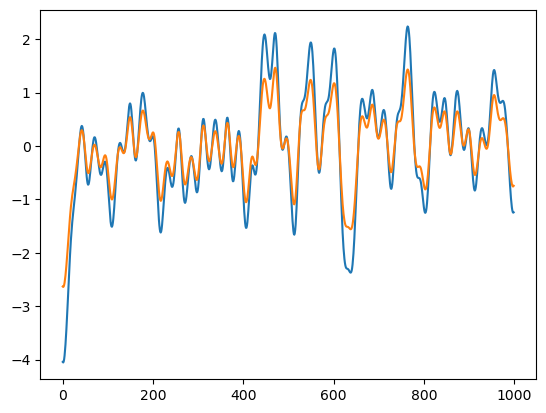

In [28]:
import matplotlib.pyplot as plt
plt.plot(scaled_e)
plt.plot(lr_cat.predict(scaled_rep))

# We see that we are overfitting on the forces, and underfitting on the energies.
We may get better results by selectively sampling a fraction of forces.

In [29]:
# Prepare the feature matrix: concatenate the normalized features and the normalized negative of the three feature gradients) 
# Here, we will do things more properly and retain the actual scalers used, so we can inverse transform later.
# We also select n random force_x, force_y, and force_z components
# Try n=250 (doesn't improve things)
# Try n=100 (improves a bit: energies up to r^2=89%)
rng = np.random.default_rng(12323898)
n=250
# n = 250   # doesn't work well, energy r^2 still at 87%
# n = 100     # energy r^2 raised to 89%
# n = 50    # energy r^2 87%
indices = rng.permutation(np.arange(0, 12000))   

rep_scaler = StandardFlexibleScaler(column_wise=False)
grad_x_scaler = StandardFlexibleScaler(column_wise=False)
grad_y_scaler = StandardFlexibleScaler(column_wise=False)
grad_z_scaler = StandardFlexibleScaler(column_wise=False)

rep_scaler.fit(rep.block().values.squeeze())
grad_x_scaler.fit(rep.block().gradient("positions").values[indices[:n],0,:])
grad_y_scaler.fit(rep.block().gradient("positions").values[indices[:n],1,:])
grad_z_scaler.fit(rep.block().gradient("positions").values[indices[:n],2,:])

scaled_rep = rep_scaler.transform(rep.block().values.squeeze())
scaled_grad_x = grad_x_scaler.transform(rep.block().gradient("positions").values[indices[:n],0,:])
scaled_grad_y = grad_y_scaler.transform(rep.block().gradient("positions").values[indices[:n],1,:])
scaled_grad_z = grad_z_scaler.transform(rep.block().gradient("positions").values[indices[:n],2,:])

# Don't forget these negative signs on the gradients!
rep_cat = np.vstack((scaled_rep, -scaled_grad_x, -scaled_grad_y, -scaled_grad_z))
print(rep_cat.shape)

# Now, prepare the concatenated targets
e_scaler = StandardFlexibleScaler(column_wise=False)
f_x_scaler = StandardFlexibleScaler(column_wise=False)
f_y_scaler = StandardFlexibleScaler(column_wise=False)
f_z_scaler = StandardFlexibleScaler(column_wise=False)

e_scaler.fit(energies[:n_frames])
f_x_scaler.fit(forces[:, :, 0].flatten().reshape(-1,1)[indices[:n]])
f_y_scaler.fit(forces[:, :, 1].flatten().reshape(-1,1)[indices[:n]])
f_z_scaler.fit(forces[:, :, 2].flatten().reshape(-1,1)[indices[:n]])

scaled_e = e_scaler.transform(energies[:n_frames].reshape(-1,1))
scaled_f_x = f_x_scaler.transform(forces[:, :, 0].flatten().reshape(-1,1)[indices[:n]])
scaled_f_y = f_y_scaler.transform(forces[:, :, 1].flatten().reshape(-1,1)[indices[:n]])
scaled_f_z = f_z_scaler.transform(forces[:, :, 2].flatten().reshape(-1,1)[indices[:n]])

y_cat = np.vstack((scaled_e, scaled_f_x, scaled_f_y, scaled_f_z))
print(y_cat.shape)

(1750, 735)
(1750, 1)


In [30]:
lr_cat2 = RidgeCV(alphas=np.logspace(-8, 2, 10), cv=5)
lr_cat2.fit(rep_cat, y_cat)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+02])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [31]:
scaled_f_x.shape

(250, 1)

In [32]:
print(lr_cat2.score(rep_cat, y_cat))
print(lr_cat2.score(scaled_rep, scaled_e))
print(lr_cat2.score(-scaled_grad_x, scaled_f_x))
print(lr_cat2.score(-scaled_grad_y, scaled_f_y))
print(lr_cat2.score(-scaled_grad_z, scaled_f_z))

0.9773393937184615
0.9823173575259919
0.986963067833238
0.9686888282819999
0.9564544298100249


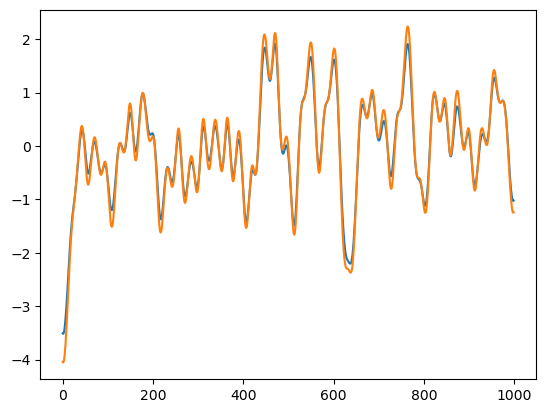

In [33]:
import matplotlib.pyplot as plt 
plt.plot(lr_cat2.predict(scaled_rep))
plt.plot(scaled_e)

In [34]:
1000/3.82929 / 6.022

43.36516380589153

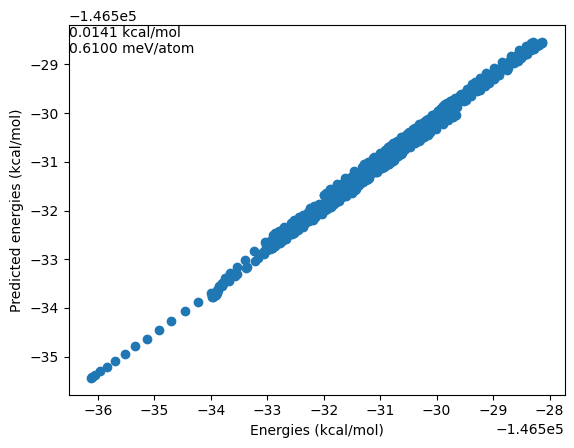

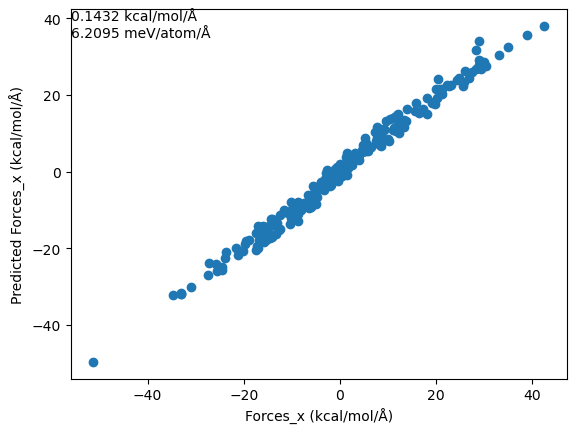

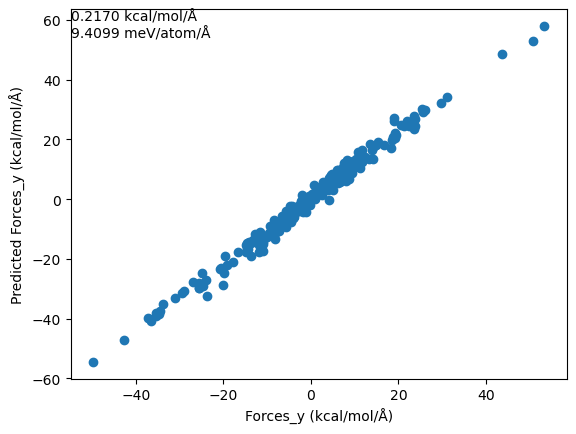

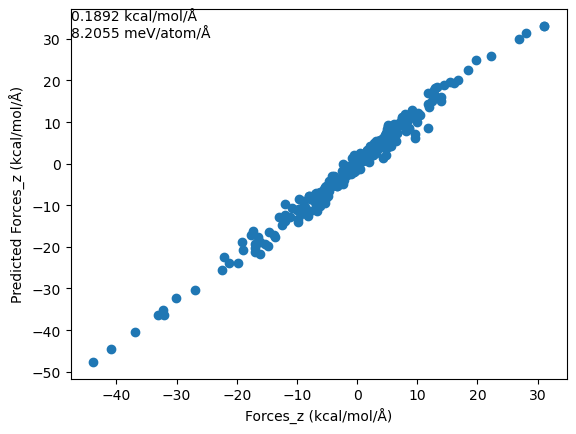

In [35]:
from sklearn.metrics import root_mean_squared_error as rmse 
def plot_parity(y, ypred, xlabel, ylabel, text):
    
    plt.scatter(y, ypred)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.text(0, 1, text, 
             verticalalignment='top',
             transform=plt.gca().transAxes)
    plt.show()

# Energies
# Transform from kcal/mol to meV/atom. 1 kcal/mol = 43 meV/atom
y = e_scaler.inverse_transform(scaled_e)
ypred = e_scaler.inverse_transform(lr_cat2.predict(scaled_rep).reshape(-1, 1),)
convert = 1000 / 3.82929 / 6.022
rmse_kcal_mol = rmse(y, ypred)/12
rmse_meV_atom = rmse_kcal_mol * convert
text = f"{rmse_kcal_mol:.4f} kcal/mol\n{rmse_meV_atom:.4f} meV/atom"
plot_parity(y, ypred, "Energies (kcal/mol)", "Predicted energies (kcal/mol)", text)

# Force x
y = f_x_scaler.inverse_transform(scaled_f_x)
ypred = f_x_scaler.inverse_transform(lr_cat2.predict(-scaled_grad_x).reshape(-1, 1),)
convert = 1000 / 3.82929 / 6.022
rmse_kcal_mol = rmse(y, ypred)/12
rmse_meV_atom = rmse_kcal_mol * convert
text = f"{rmse_kcal_mol:.4f} kcal/mol/Å\n{rmse_meV_atom:.4f} meV/atom/Å"
plot_parity(y, ypred, "Forces_x (kcal/mol/Å)", "Predicted Forces_x (kcal/mol/Å)", text)

# Force y
y = f_y_scaler.inverse_transform(scaled_f_y)
ypred = f_y_scaler.inverse_transform(lr_cat2.predict(-scaled_grad_y).reshape(-1, 1),)
convert = 1000 / 3.82929 / 6.022
rmse_kcal_mol = rmse(y, ypred)/12
rmse_meV_atom = rmse_kcal_mol * convert
text = f"{rmse_kcal_mol:.4f} kcal/mol/Å\n{rmse_meV_atom:.4f} meV/atom/Å"
plot_parity(y, ypred, "Forces_y (kcal/mol/Å)", "Predicted Forces_y (kcal/mol/Å)", text)

# Force z
y = f_z_scaler.inverse_transform(scaled_f_z)
ypred = f_z_scaler.inverse_transform(lr_cat2.predict(-scaled_grad_z).reshape(-1, 1),)
convert = 1000 / 3.82929 / 6.022
rmse_kcal_mol = rmse(y, ypred)/12
rmse_meV_atom = rmse_kcal_mol * convert
text = f"{rmse_kcal_mol:.4f} kcal/mol/Å\n{rmse_meV_atom:.4f} meV/atom/Å"
plot_parity(y, ypred, "Forces_z (kcal/mol/Å)", "Predicted Forces_z (kcal/mol/Å)", text)

# Here are the r^2 scores for different n. For whatever reason, the z-gradient consistently struggles.
n=100
* 0.9706606852957382
* 0.9799756189721461
* 0.9637474966094911
* 0.9642484187028344
* 0.8908368038108095

n=250
* 0.9615897837589861
* 0.9685667094707952
* 0.9735596604916735
* 0.9698332802507261
* 0.9134687076873225

n=500
* 0.9741212844211025
* 0.9703005014232481
* 0.9909679390705148
* 0.9892771801713631
* 0.9497603000171384

n = 1000
* 0.9624471289275044
* 0.9328607020540104
* 0.9809782312141057
* 0.9895349815034322
* 0.9464146009384695

# AniSOAP Gradients<a class="anchor" id="anisoap"></a>
At last, we see if the gradients I manually implemented can learn forces.

In [163]:
from anisoap.representations import EllipsoidalDensityProjection
# create 1000 frames for featomic
frames = []
for i in range(n_frames):
    frame = Atoms(symbols=atom_numbers, positions=positions[i])
    frame.arrays["c_diameter[1]"] = np.ones(len(frame))
    frame.arrays["c_diameter[2]"] = np.ones(len(frame))
    frame.arrays["c_diameter[3]"] = np.ones(len(frame))
    frame.arrays["c_q"] = np.array([[1,0,0,0]]*len(frame))
    frames.append(frame)

In [164]:
print(len(frames))
frames[0].arrays

100


{'numbers': array([6, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 1]),
 'positions': array([[ 0.    ,  1.397 ,  0.    ],
        [ 1.2098,  0.6985,  0.    ],
        [ 1.2098, -0.6985,  0.    ],
        [ 0.    , -1.397 ,  0.    ],
        [-1.2098, -0.6985,  0.    ],
        [-1.2098,  0.6985,  0.    ],
        [ 0.    ,  2.481 ,  0.    ],
        [ 2.1486,  1.2405,  0.    ],
        [ 2.1486, -1.2405,  0.    ],
        [ 0.    , -2.481 ,  0.    ],
        [-2.1486, -1.2405,  0.    ],
        [-2.1486,  1.2405,  0.    ]]),
 'c_diameter[1]': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'c_diameter[2]': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'c_diameter[3]': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'c_q': array([[1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1

In [165]:
lmax = 5
nmax = 3

AniSOAP_HYPERS = {
    "max_angular": lmax,
    "max_radial": nmax,
    "radial_basis_name": "gto",
    "rotation_type": "quaternion",
    "rotation_key": "c_q",
    "cutoff_radius": 7.0,
    "radial_gaussian_width": 1.5,
    "basis_rcond": 1e-8,
    "basis_tol": 1e-4,
}
calculator = EllipsoidalDensityProjection(**AniSOAP_HYPERS)


/Users/alin62/Documents/Research/anisoap/anisoap/representations/ellipsoidal_density_projection.py:636: UserWarning: In quaternion mode, quaternions are assumed to be in (w,x,y,z) format.
  warnings.warn(


In [167]:
# Takes time
mvg_coeffs = calculator.transform(frames, show_progress=True, normalize=True, rust_moments=False, compute_gradients=True)

Computing neighborlist: 100%|██████████| 100/100 [00:00<00:00, 4451.13it/s]


In [168]:
from anisoap.utils.metatensor_utils import (
    ClebschGordanReal,
    cg_combine,
    standardize_keys,
)
import metatensor

mvg_nu1 = standardize_keys(mvg_coeffs)  # standardize the metadata naming schemes
# Create an object that stores Clebsch-Gordan coefficients for a certain lmax:
mycg = ClebschGordanReal(lmax)

# Combines the mvg_nu1 with itself using the Clebsch-Gordan coefficients.
# This combines the angular and radial components of the sample.
mvg_nu2 = cg_combine(
    mvg_nu1,
    mvg_nu1,
    clebsch_gordan=mycg,
    lcut=0,
    other_keys_match=["types_center"],
)


In [169]:
mvg_nu1.block(0).gradient("positions")

Gradient TensorBlock ('positions')
    samples (7200): ['sample', 'system', 'atom']
    components (3, 1): ['xyz', 'spherical_component_m']
    properties (8): ['neighbor_types_1', 'n_1']
    gradients: None

In [170]:
mvg_nu2_avg = metatensor.mean_over_samples(mvg_nu2, sample_names="center")

In [171]:
mvg_nu2_avg.block(0).gradient("positions")

Gradient TensorBlock ('positions')
    samples (1200): ['sample', 'system', 'atom']
    components (3, 1): ['xyz', 'spherical_harmonics_m']
    properties (384): ['neighbor_types_1_a', 'n_1_a', 'k_2', 'neighbor_types_1_b', 'n_1_b', 'l_2']
    gradients: None

(100, 768) (1200, 768)


In [332]:
mvg_nu2_avg.block(0).gradient("positions")

Gradient TensorBlock ('positions')
    samples (1200): ['sample', 'system', 'atom']
    components (3, 1): ['xyz', 'spherical_harmonics_m']
    properties (384): ['neighbor_types_1_a', 'n_1_a', 'k_2', 'neighbor_types_1_b', 'n_1_b', 'l_2']
    gradients: None

(100, 768) (1200, 768)
-939.3785975969093
0.9997699131353676


Text(0, 0.5, 'predicted e')

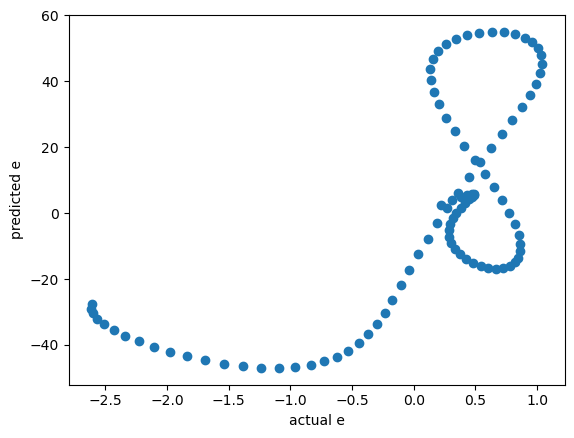

In [341]:
x_anisoap_raw = np.hstack([block.values.squeeze() for block in mvg_nu2_avg.blocks()])
x_anisoap_gradx = np.hstack([block.gradient("positions").values[:,0,:,:].squeeze() for block in mvg_nu2_avg.blocks()])
print(x_anisoap_raw.shape, x_anisoap_gradx.shape)

# No train test split for now, just see if I can learn the forces from the energy coeffs, for the power spectrum
x_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_raw)
x = x_scaler.transform(x_anisoap_raw)   # (100, 768)
x_gradx_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_gradx)
x_gradx = x_gradx_scaler.transform(x_anisoap_gradx)    # (1200, 768)

e_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[np.arange(100)])
e = e_scaler.transform(energies[np.arange(100)])
fx_scaler = StandardFlexibleScaler(column_wise=True).fit(forces[np.arange(100), :, 0].reshape(-1,1))
fx = fx_scaler.transform(forces[np.arange(100), :, 0].reshape(-1,1))

from sklearn.linear_model import RidgeCV
lr = RidgeCV(alphas=np.logspace(-8,2,10), cv=5)
lr.fit(-x_gradx,fx)
print(lr.score(x,e))
print(lr.score(-x_gradx, fx))

plt.scatter(e, lr.predict(x))
plt.xlabel("actual e")
plt.ylabel("predicted e")

# Shit sucks

In [311]:
mvg_nu1_mean = metatensor.mean_over_samples(mvg_nu1, "center")
mvg_nu1_mean = mvg_nu1_mean.components_to_properties("spherical_component_m")
mvg_nu1_mean = mvg_nu1_mean.keys_to_properties("types_center")
mvg_nu1_mean = mvg_nu1_mean.keys_to_properties("angular_channel")
mvg_nu1_mean.block()

x_anisoap_raw = mvg_nu1_mean.block().values.squeeze()
x_anisoap_gradx = mvg_nu1_mean.block().gradient("positions").values[:,0,:].squeeze()

# No train test split for now, just see if i can learn things from the radial spectrum
x_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_raw)
x = x_scaler.transform(x_anisoap_raw)   # (100, 768)
x_gradx_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_gradx)
x_gradx = x_gradx_scaler.transform(x_anisoap_gradx)    # (1200, 768)

e_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[np.arange(100)])
e = e_scaler.transform(energies[np.arange(100)])
fx_scaler = StandardFlexibleScaler(column_wise=True).fit(forces[np.arange(100), :, 0].reshape(-1,1))
fx = fx_scaler.transform(forces[np.arange(100), :, 0].reshape(-1,1))

from sklearn.linear_model import RidgeCV
lr = RidgeCV(alphas=np.logspace(-8,2,10), cv=5)
lr.fit(x, e)
print(lr.score(x,e))
print(lr.score(-x_gradx, fx))

0.9999785379034967
-6.688658223036177


In [230]:
forces[np.arange(100)].shape

(100, 12, 3)

In [228]:
forces[i_train, :, 0].shape

(90, 12)

In [214]:
gradx_train.shape

(90, 576)

In [ ]:
# Energies and Forces
from skmatter.preprocessing import StandardFlexibleScaler
from sklearn.model_selection import train_test_split

i_train, i_test = train_test_split(np.arange(100), train_size=0.9, shuffle=True)
x_train_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_raw[i_train])
x_train = x_train_scaler.transform(x_anisoap_raw[i_train])
gradx_train_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_gradx[i_train])
gradx_train = grad_xtrain_scaler.transform(x_anisoap_gradx[i_train])

y_train_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[i_train])
y_train = y_train_scaler.transform(energies[i_train])
forces_x_train_scaler = StandardFlexibleScaler(column_wise=True).fit(forces[i_train])
x_test_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_raw[i_test])
x_test = x_test_scaler.transform(x_anisoap_raw[i_test])
y_test_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[i_test])
y_test = y_test_scaler.transform(energies[i_test])

from sklearn.linear_model import RidgeCV

lr = RidgeCV(cv=5, alphas=np.logspace(-8, 2, 20), fit_intercept=True)
lr.fit(x_train, y_train)
print(f"{lr.alpha_=:.3f}")
print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))


lr.alpha_=0.000
0.9999995695446736
0.8812080886842215


In [196]:
mvg_nu2_avg.block(0).gradient("positions").values[:,0,0,:].shape

(1200, 384)

In [197]:
# Now, try doing forces
x_anisoap_raw_gradx = np.hstack([block.gradient("positions").values[:,0,0,:].squeeze() for block in mvg_nu2_avg.blocks()])

In [200]:
forces_x = forces[:100, :, 0].flatten().reshape(-1,1)

In [201]:
# Forces
from skmatter.preprocessing import StandardFlexibleScaler
from sklearn.model_selection import train_test_split

i_train, i_test = train_test_split(np.arange(100), train_size=0.9, shuffle=True)
gradx_train_scaler = StandardFlexibleScaler(column_wise=False).fit(x_anisoap_raw_gradx[i_train])
gradx_train = gradx_train_scaler.transform(radial_gradx[i_train])
forces_x_train_scaler = StandardFlexibleScaler(column_wise=True).fit(forces_x[i_train])
forces_x_train = forces_x_train_scaler.transform(forces_x[i_train])

gradx_test_scaler = StandardFlexibleScaler(column_wise=False).fit(radial_gradx[i_test])
gradx_test = gradx_test_scaler.transform(x_anisoap_raw_gradx[i_test])
forces_x_test_scaler = StandardFlexibleScaler(column_wise=True).fit(forces_x[i_test])
forces_x_test = forces_x_test_scaler.transform(forces_x[i_test])

from sklearn.linear_model import RidgeCV

lr = RidgeCV(cv=5, alphas=np.logspace(-8, 2, 20), fit_intercept=True)
lr.fit(gradx_train, forces_x_train)
print(f"{lr.alpha_=:.3f}")
print(lr.score(gradx_train, forces_x_train))
print(lr.score(gradx_test, forces_x_test))


ValueError: X has 576 features, but StandardFlexibleScaler is expecting 768 features as input.

In [189]:
# Now, using the coefficients of energy for forces
# lr.fit(-gradx_train, forces_x_train)
lr.fit(x_train, y_train)
print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))
print(lr.score(-gradx_train, forces_x_train))
print(lr.score(-gradx_test, forces_x_test))

0.9999995545629526
0.9347581998256068


ValueError: X has 576 features, but RidgeCV is expecting 768 features as input.

In [ ]:
# For now, this doesn't work - it probably needs normalization.
# How does mvg_nu1 work?

mvg_nu1_summed = metatensor.sum_over_samples(mvg_nu1, sample_names=['center'])
mvg_nu1_summed.block(0)

TensorBlock
    samples (1000): ['system']
    components (1): ['spherical_component_m']
    properties (8): ['neighbor_types_1', 'n_1']
    gradients: ['positions']

In [144]:
mvg_nu1_summed

TensorMap with 12 blocks
keys: order_nu  types_center  angular_channel
         1           1               0
         1           1               1
                       ...
         1           6               4
         1           6               5

In [145]:
radial = mvg_nu1_summed.components_to_properties(["spherical_component_m"])
radial = radial.keys_to_properties(["angular_channel", "types_center"])
radial.block()

TensorBlock
    samples (1000): ['system']
    components (): []
    properties (576): ['angular_channel', 'types_center', 'spherical_component_m', 'neighbor_types_1', 'n_1']
    gradients: ['positions']

In [152]:
# Energies from radial
from skmatter.preprocessing import StandardFlexibleScaler
from sklearn.model_selection import train_test_split
radial_rep = radial.block().values.squeeze()
i_train, i_test = train_test_split(np.arange(100), train_size=0.9, shuffle=True)
x_train_scaler = StandardFlexibleScaler(column_wise=False).fit(radial_rep[i_train])
x_train = x_train_scaler.transform(radial_rep[i_train])
y_train_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[i_train])
y_train = y_train_scaler.transform(energies[i_train])

x_test_scaler = StandardFlexibleScaler(column_wise=False).fit(radial_rep[i_test])
x_test = x_test_scaler.transform(radial_rep[i_test])
y_test_scaler = StandardFlexibleScaler(column_wise=True).fit(energies[i_test])
y_test = y_test_scaler.transform(energies[i_test])

from sklearn.linear_model import RidgeCV

lr = RidgeCV(cv=5, alphas=np.logspace(-8, 2, 20), fit_intercept=True)
lr.fit(x_train, y_train)
print(f"{lr.alpha_=:.3f}")
print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))

lr.alpha_=0.000
0.9999696316135007
0.9933995692079749


In [153]:
radial.block().gradient("positions")

Gradient TensorBlock ('positions')
    samples (12000): ['sample', 'system', 'atom']
    components (3): ['xyz']
    properties (576): ['angular_channel', 'types_center', 'spherical_component_m', 'neighbor_types_1', 'n_1']
    gradients: None

In [155]:
# Forces from Radial
from skmatter.preprocessing import StandardFlexibleScaler
from sklearn.model_selection import train_test_split
radial_gradx = radial.block().gradient("positions").values[:, 0, :]
i_train, i_test = train_test_split(np.arange(100), train_size=0.9, shuffle=True)
gradx_train_scaler = StandardFlexibleScaler(column_wise=False).fit(radial_gradx[i_train])
gradx_train = gradx_train_scaler.transform(radial_gradx[i_train])
forces_x_train_scaler = StandardFlexibleScaler(column_wise=True).fit(forces_x[i_train])
forces_x_train = forces_x_train_scaler.transform(forces_x[i_train])

gradx_test_scaler = StandardFlexibleScaler(column_wise=False).fit(radial_gradx[i_test])
gradx_test = gradx_test_scaler.transform(radial_gradx[i_test])
forces_x_test_scaler = StandardFlexibleScaler(column_wise=True).fit(forces_x[i_test])
forces_x_test = forces_x_test_scaler.transform(forces_x[i_test])

from sklearn.linear_model import RidgeCV

lr = RidgeCV(cv=5, alphas=np.logspace(-8, 2, 20), fit_intercept=True)
lr.fit(gradx_train, forces_x_train)
print(f"{lr.alpha_=:.3f}")
print(lr.score(gradx_train, forces_x_train))
print(lr.score(gradx_test, forces_x_test))


lr.alpha_=0.000
0.9995664432372737
0.9661683965820548


In [159]:
# Now, forces from energy coeffs
lr.fit(x_train, y_train)
print(f"{lr.alpha_=:.3f}")
print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))
print(lr.score(-gradx_train, forces_x_train))
print(lr.score(-gradx_test, forces_x_test))

lr.alpha_=0.000
0.9999696316135007
0.9933995692079749
-3382.651876770579
-416.11925950448955


Train R^2: 1.000
Test R^2: 0.998


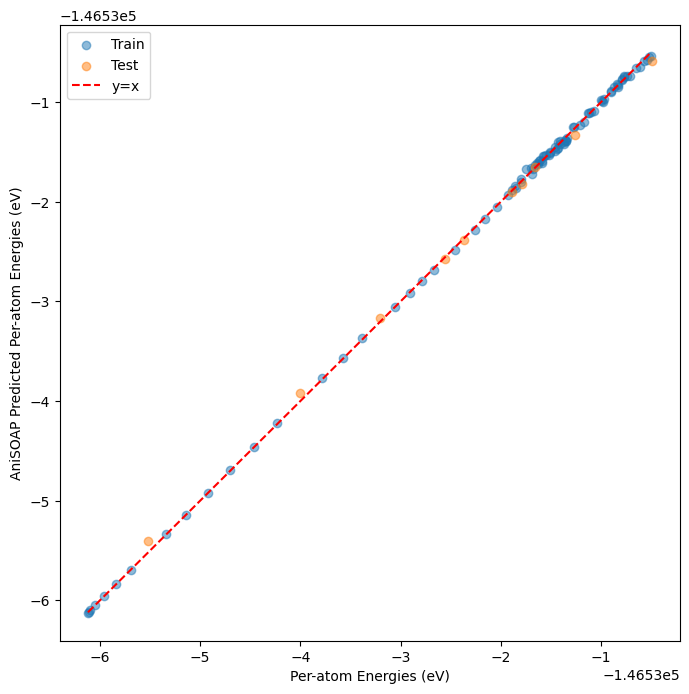

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    y_train_scaler.inverse_transform(y_train),
    y_train_scaler.inverse_transform(lr.predict(x_train).reshape(-1, 1)),
    alpha=0.5,
)

plt.scatter(
    y_test_scaler.inverse_transform(y_test),
    y_test_scaler.inverse_transform(lr.predict(x_test).reshape(-1, 1)),
    alpha=0.5,
)

plt.plot(
    [np.min(y_train_scaler.inverse_transform(y_train)), np.max(y_train_scaler.inverse_transform(y_train))], [np.min(y_train_scaler.inverse_transform(y_train)), np.max(y_train_scaler.inverse_transform(y_train))], "r--"
)
plt.xlabel("Per-atom Energies (eV)")
plt.ylabel("AniSOAP Predicted Per-atom Energies (eV)")
plt.legend(["Train", "Test", "y=x"])

print(f"Train R^2: {lr.score(x_train, y_train):.3f}")
print(f"Test R^2: {lr.score(x_test, y_test):.3f}")


In [82]:
mvg_coeffs.block(0)

TensorBlock
    samples (600): ['system', 'center']
    components (1): ['spherical_component_m']
    properties (8): ['neighbor_types', 'n']
    gradients: ['positions']

In [94]:
mvg_coeffs.block(0).has_gradient("positions")

True

In [93]:
mvg_nu1.block(0).has_gradient("positions")

False

In [71]:
lr.score(x_test, y_test)

0.9643230252581205